# Stochastic Shape Processes on the Tree: Simulation and Inference (Lagrangian framework)

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from hyperiax.tree import HypTree
from hyperiax.tree.topology import symmetric_topology
from hyperiax.execution import OrderedExecutor
from hyperiax.models import DownLambda, UpLambdaReducer
from hyperiax.mcmc import ParameterStore, VarianceParameter
from hyperiax.mcmc.samplers import (
    PCNNoiseSampler, 
    MHParametersSampler, 
    GibbsParametersSampler, 
    CanonicalStateSampler, 
    AlternatingStateSampler, 
    MetropolisHastingsSampler
)

In [3]:
jax.config.update("jax_enable_x64", True)
SEED = 42
key = jr.key(SEED)

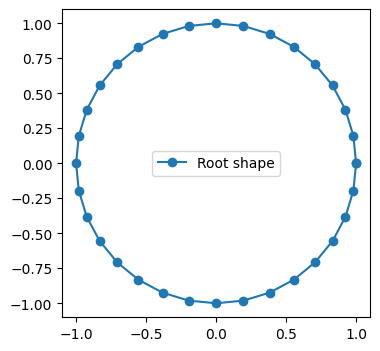

In [4]:
n_pts = 32
thetas = jnp.linspace(0, 2. * jnp.pi, n_pts, endpoint=False)
root_shape = jnp.stack([jnp.cos(thetas), jnp.sin(thetas)], axis=-1)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
closed_root_curve = jnp.concatenate([root_shape, root_shape[:1]], axis=0)
ax.plot(closed_root_curve[:, 0], closed_root_curve[:, 1], '-o', label='Root shape')
ax.legend()
ax.set_aspect('equal')
plt.show()

In [5]:
def matern_52(d, alpha, sigma):
    sigma = jnp.maximum(sigma, 1e-9)
    r = d / sigma
    # return alpha * (1. + jnp.sqrt(5.) * r + 5. * r**2 / 3.) * jnp.exp(-jnp.sqrt(5.) * r)
    return alpha**2 * (1. + r + (45 / 105) * r**2 + (10 / 105) * r**3 + (1 / 105) * r**4) * jnp.exp(-r)
    
def f(x, params):
    return jnp.zeros_like(x)

def a(x, params):
    d_mat = jnp.sqrt(
        jnp.sum(
            jnp.square(x[:, None, :] - x[None, :, :]),
            axis=-1
        )
    )
    return matern_52(d_mat, params['k_alpha'], params['k_sigma'])

def g(x, params):
    q = a(x, params)
    q_half = jax.scipy.linalg.cholesky(q, lower=True, check_finite=False)
    return q_half

def integrate(f, g, params, x0, dts, dws):
    
    def scan_body(carry, inputs):
        x_prev = carry
        dt, dw = inputs
        drift = f(x_prev, params) * dt
        diffusion = g(x_prev, params) @ dw
        x_next = x_prev + drift + diffusion
        return x_next, x_next
    
    xT, _ = jax.lax.scan(
        scan_body, 
        init=x0, 
        xs=(dts, dws),
        length=dts.shape[0])
    return xT

In [6]:
topo = symmetric_topology(2, 5)
tree = HypTree(topo, dtype=jnp.float64)
print(tree)

HypTree:
Topology:
                        o
    ┌─────────┬─────────┼─────────┬─────────┐
    o         o         o         o         o    
┌─┬─┼─┬─┐ ┌─┬─┼─┬─┐ ┌─┬─┼─┬─┐ ┌─┬─┼─┬─┐ ┌─┬─┼─┬─┐
o o o o o o o o o o o o o o o o o o o o o o o o o
Statistics:
total number of nodes = 31
number of levels = 3
number of leaves = 25
number of inner nodes = 5


In [7]:
params = ParameterStore({
    'k_alpha': VarianceParameter(0.1, keep_constant=True),
    'k_sigma': VarianceParameter(0.25, keep_constant=True),
    'obs_var': VarianceParameter(0.001, keep_constant=True),
})

In [8]:
num_int_steps = 100

tree.add_property('edge_length', shape=())
tree.add_property('value', shape=(n_pts, 2))
tree.add_property('noise', shape=(num_int_steps, n_pts, 2))

tree.data['edge_length'] = jnp.ones_like(tree.data['edge_length'])
tree.data['value'] = tree.data['value'].at[0].set(root_shape) 
tree.data['noise'] = jr.normal(key, shape=tree.data['noise'].shape)

In [9]:
@jax.jit
def down_fn(parent_value, edge_length, noise, params, *args, **kwargs):
    
    def single_down(parent_value, edge_length, noise):
        dts = jnp.diff(jnp.linspace(0., edge_length, num_int_steps + 1))
        dws = noise * jnp.sqrt(dts[:, None, None])
        child_value = integrate(f, g, params, parent_value, dts, dws)
        return {'value': child_value}
    
    return jax.vmap(single_down)(parent_value, edge_length, noise)

down_model = DownLambda(down_fn)
down_executor = OrderedExecutor(down_model)

In [10]:
down_executor.down(tree, params.values())

In [11]:
def vis_tree_node_shapes(tree: HypTree):
    num_levels = len(tree.levels)
    
    fig, axs = plt.subplots(1, num_levels, figsize=(4 * num_levels, 4), sharex=True, sharey=True, layout='constrained')
    for level, (level_id, ax) in zip(tree.levels, enumerate(axs)):
        l_start, l_end = level
        for i, node_id in enumerate(range(l_start, l_end)):
            datum = tree.data['value'][node_id]
            closed_curve = jnp.vstack([datum, datum[0:1, :]])
            ax.plot(closed_curve[:, 0], closed_curve[:, 1], color=f'C{i}', marker='o', markersize=2, label=f'Node {i}')

        ax.set_title(f'Level {level_id}')
        ax.set_aspect('equal')
        # ax.legend()
    
    plt.show()

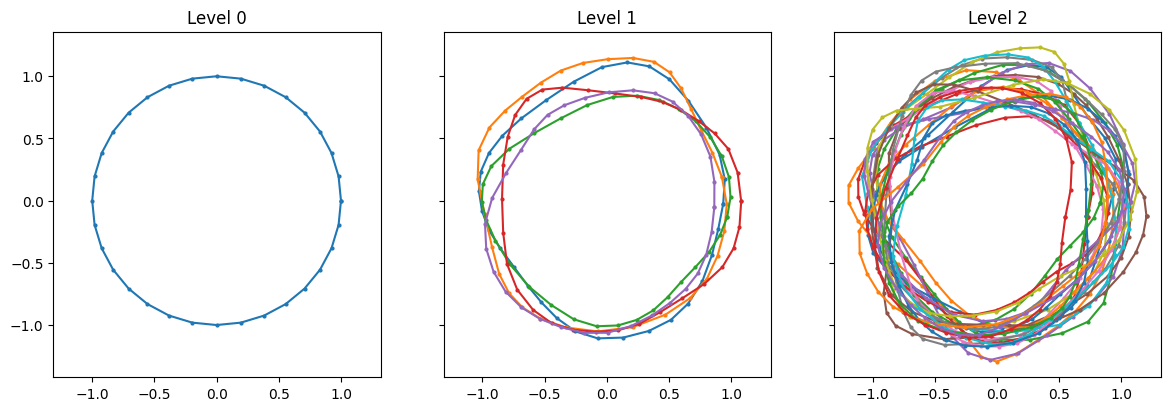

In [12]:
vis_tree_node_shapes(tree)

In [13]:
# add observation noise 
new_key, _ = jr.split(key)
leaf_shapes = tree.data['value'][tree.is_leaf]
obs_noise = jr.normal(new_key, shape=leaf_shapes.shape) * jnp.sqrt(params['obs_var'].value)
noisy_leaf_shapes = leaf_shapes + obs_noise
tree.data['value'] = tree.data['value'].at[tree.is_leaf].set(noisy_leaf_shapes)

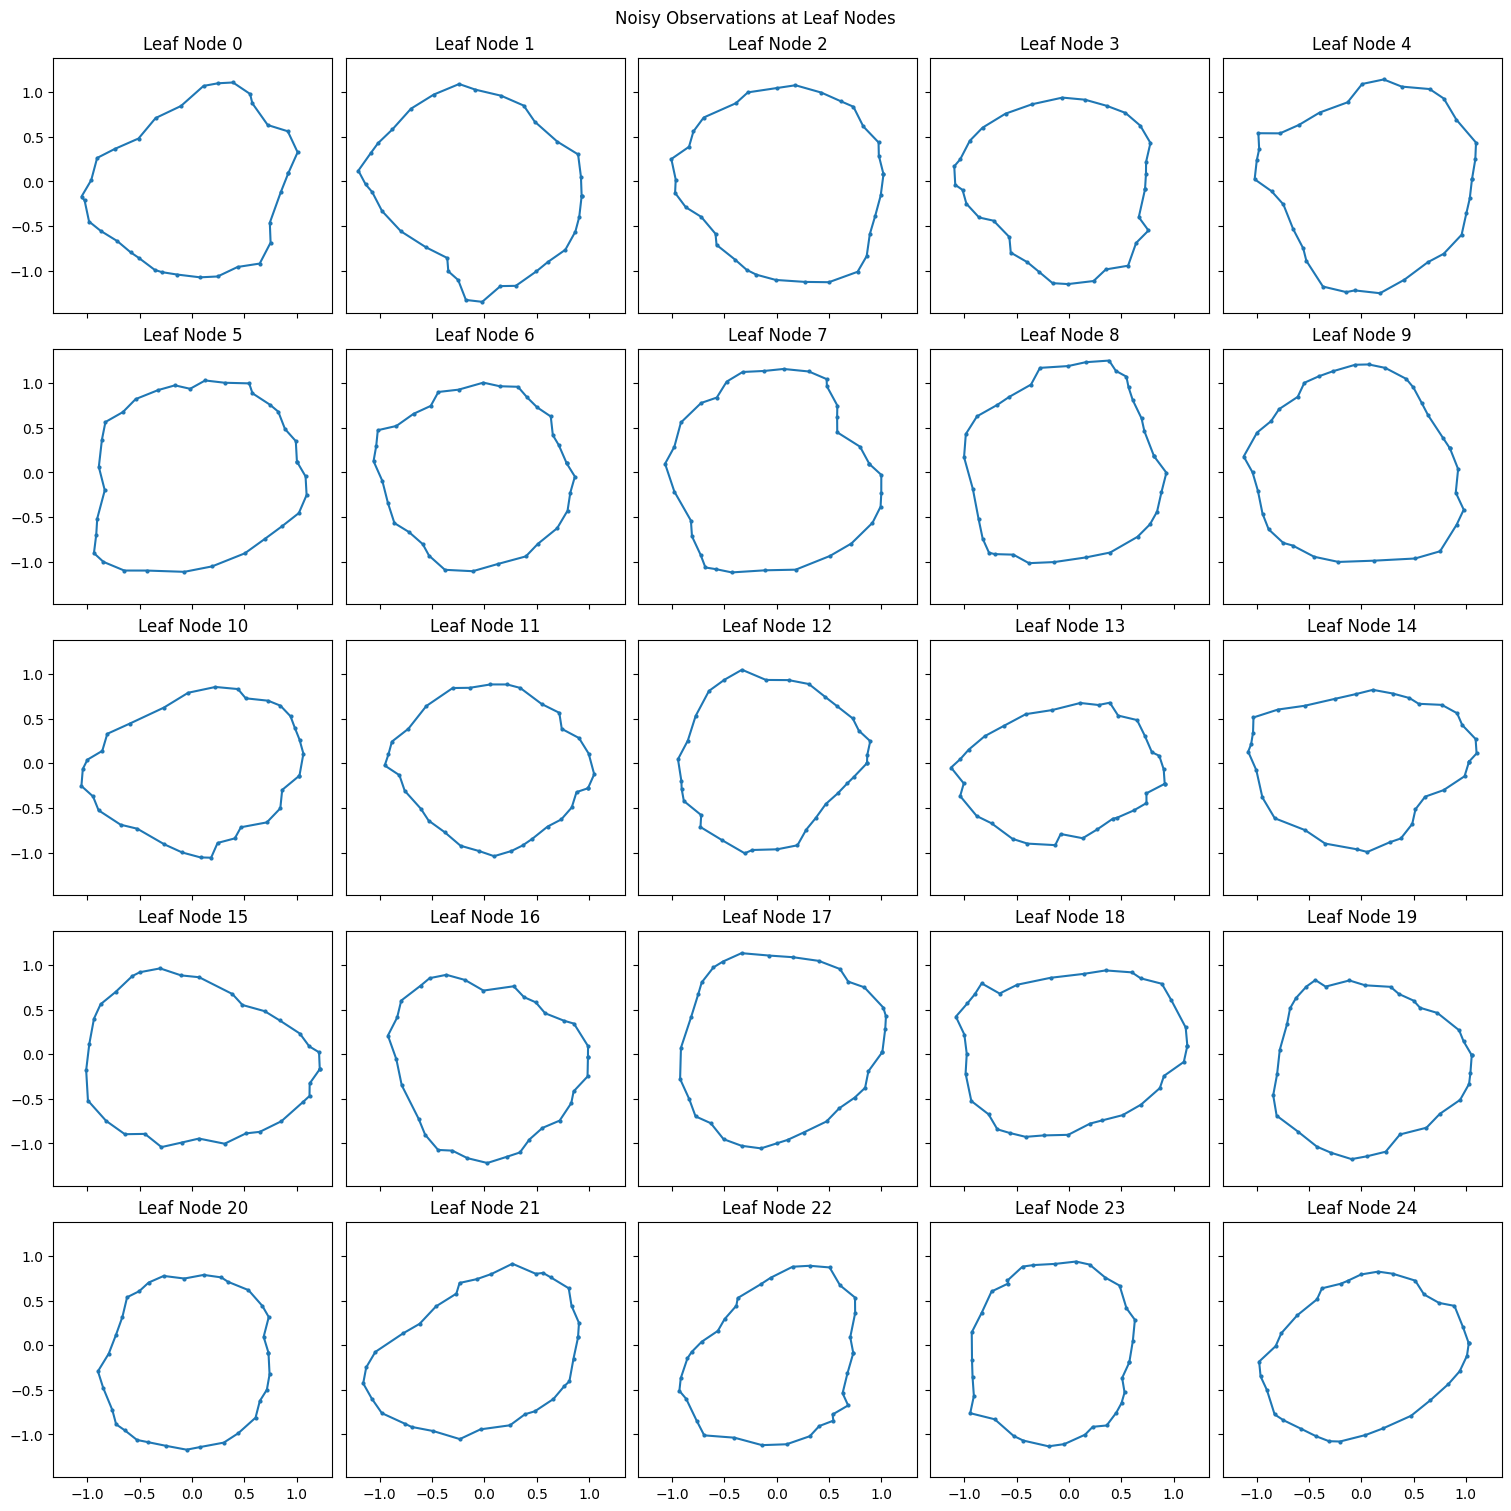

In [14]:
fig, axs = plt.subplots(5, 5, figsize=(15, 15), sharex=True, sharey=True, layout='constrained')
axs = axs.flatten()
for i, leave_node in enumerate(list(tree.iter_topology_leaves_bfs())):
    datum = tree.data['value'][leave_node.id]
    closed_curve = jnp.vstack([datum, datum[0:1, :]])
    axs[i].plot(closed_curve[:, 0], closed_curve[:, 1], color='C0', marker='o', markersize=2)
    axs[i].set_title(f'Leaf Node {i}')
fig.suptitle('Noisy Observations at Leaf Nodes')
plt.show()

In [15]:
tree.add_property('c0', shape=(2, ))
tree.add_property('cT', shape=(2, ))
tree.add_property('F0', shape=(n_pts, 2))
tree.add_property('FT', shape=(n_pts, 2))
tree.add_property('H0', shape=(n_pts, n_pts))
tree.add_property('HT', shape=(n_pts, n_pts))

tree.add_property('log_Psi', shape=())
tree.add_property('tilde_a', shape=(n_pts, n_pts))

In [16]:
# set leave nodes (observations) with the current params
def init_up(tree, leaf_observations, params):
    HT = jnp.eye(n_pts) / params['obs_var'].value
    FT = jnp.einsum('ij,bjk->bik', HT, leaf_observations)
    cT = jax.vmap( # over batch dimension
        jax.vmap( # over spatial dimension
            lambda x: jax.scipy.stats.multivariate_normal.logpdf(
                x,
                mean=jnp.zeros((n_pts, )),
                cov=params['obs_var'].value * jnp.eye(n_pts)
            ),
            in_axes=-1,
            out_axes=0
        ),
        in_axes=0,
        out_axes=0
    )(leaf_observations)

    tilde_aT = jax.vmap(
        lambda x: a(x, params.values()),
        in_axes=0,
        out_axes=0
    )(leaf_observations)
    
    tree.data['HT'] = tree.data['HT'].at[tree.is_leaf].set(HT[None, :, :]) # automatically broadcast to all leaf nodes
    tree.data['FT'] = tree.data['FT'].at[tree.is_leaf].set(FT) 
    tree.data['cT'] = tree.data['cT'].at[tree.is_leaf].set(cT)
    tree.data['tilde_a'] = tree.data['tilde_a'].at[tree.is_leaf].set(tilde_aT)

In [17]:
# some helper functions
def quadratic_form(x, A):
    return x.T @ A @ x

def log_omega_H(H):
    return 0.5 * (jnp.linalg.slogdet(H)[1] - jnp.log(2. * jnp.pi) * H.shape[0])

def log_phi_H(x, mu, H):
    return log_omega_H(H) - 0.5 * quadratic_form(x - mu, H)

@jax.jit
def up_fn(FT, HT, tilde_a, edge_length, noise, params, *args, **kwargs):
    
    def single_up(FT, HT, tilde_a, edge_length, noise):
        T = edge_length
        
        def Phi_inv(t):
            return jnp.eye(n_pts) + HT @ tilde_a * (T - t)
        
        parent_H0 = jnp.linalg.solve(Phi_inv(t=0), HT)
        parent_F0 = jnp.linalg.solve(Phi_inv(t=0), FT)
        
        vT = jnp.linalg.solve(HT, FT)
        
        parent_c0 = jax.vmap(
            lambda v: log_phi_H(v, jnp.zeros((n_pts, )), parent_H0),
            in_axes=-1,
            out_axes=0
        )(vT)
        
        return {
            'H0': parent_H0,
            'F0': parent_F0,
            'c0': parent_c0
        }
        
    return jax.vmap(single_up)(FT, HT, tilde_a, edge_length, noise)

# fusion function, where at each branching node, we fuse c, F, H by additions
def transform_fn(child_c0, child_F0, child_H0, params, **kwargs):
    cT, FT, HT = child_c0, child_F0, child_H0
    vT = jax.vmap(
        jnp.linalg.solve,
        in_axes=(0, 0),
        out_axes=0
    )(HT, FT)
    tilde_aT = jax.vmap(
        lambda x: a(x, params),
        in_axes=0,
        out_axes=0
    )(vT)
    return {
        'HT': HT,
        'FT': FT,
        'cT': cT,
        'tilde_a': tilde_aT
    }

In [18]:
up_model = UpLambdaReducer(
    up_fn,
    transform_fn,
    reductions={
        'c0': 'sum',
        'F0': 'sum',
        'H0': 'sum'
    }
)
up_executor = OrderedExecutor(up_model)

In [19]:
# initialize the backward filter by setting leaf nodes
init_up(tree, noisy_leaf_shapes, params)
# run backward filter once from leaves to root
up_executor.up(tree, params.values())

In [20]:
def integrate_guiding(f, g, params, x0, dts, dws, HT, FT, tilde_a):
    
    def beta(t, params):
        return jnp.zeros((n_pts, 2))
    
    def B(t, params):
        return 0. * jnp.eye(n_pts)
    
    def tilde_f(t, x, params):
        return beta(t, params) + B(t, params) @ x
    
    T = jnp.sum(dts)
    
    def Phi_inv(t):
        return jnp.eye(n_pts) + HT @ tilde_a * (T - t)
    
    def H(t):
        return jnp.linalg.solve(Phi_inv(t), HT)
    
    def F(t):
        return jnp.linalg.solve(Phi_inv(t), FT)
    
    def scan_body(carry, inputs):
        t_prev, x_prev, log_Psi_prev = carry
        dt, dw = inputs
        Ht, Ft = H(t_prev), F(t_prev)
        tilde_r = Ft - Ht @ x_prev
        gt = g(x_prev, params)
        at = a(x_prev, params)
        
        x_next = x_prev + f(x_prev, params) * dt + \
            at @ tilde_r * dt + gt @ dw
        t_next = t_prev + dt
        
        a_minus_tilde_a = at - tilde_a
        f_minus_tilde_f = f(x_prev, params) - tilde_f(t_prev, x_prev, params)
        d_log_Psi = (jnp.einsum('ij,ij->', f_minus_tilde_f, tilde_r) -\
            0.5 * jnp.einsum('ij,ij->', a_minus_tilde_a, Ht) +\
            0.5 * jnp.einsum('ij,jd,id->', a_minus_tilde_a, tilde_r, tilde_r)) * dt
        log_Psi_next = log_Psi_prev + d_log_Psi
        return (t_next, x_next, log_Psi_next), (x_next)
    
    (_, _, log_Psi_T), xs = jax.lax.scan(
        scan_body,
        init=(0., x0, 0.),
        xs=(dts, dws),
        length=dts.shape[0]
    )
    xs = jnp.concatenate([x0[None, :, :], xs], axis=0)
    return xs, log_Psi_T

In [21]:
tree.add_property('path', shape=(num_int_steps + 1, n_pts, 2))

In [22]:
@jax.jit
def guiding_down_fn(parent_value, edge_length, noise, HT, FT, tilde_a, params, *args, **kwargs):
    
    def single_guiding_down(parent_value, edge_length, noise, HT, FT, tilde_a):
        dts = jnp.diff(jnp.linspace(0., edge_length, num_int_steps + 1))
        dws = noise * jnp.sqrt(dts[:, None, None])
        child_path, child_log_Psi = integrate_guiding(
            f, g, params, parent_value, dts, dws, HT, FT, tilde_a
        )
        return {'path': child_path, 'log_Psi': child_log_Psi}

    return jax.vmap(single_guiding_down)(parent_value, edge_length, noise, HT, FT, tilde_a)

In [23]:
guiding_down_model = DownLambda(guiding_down_fn)
guiding_down_executor = OrderedExecutor(guiding_down_model)

In [24]:
guiding_down_executor.down(tree, params.values())

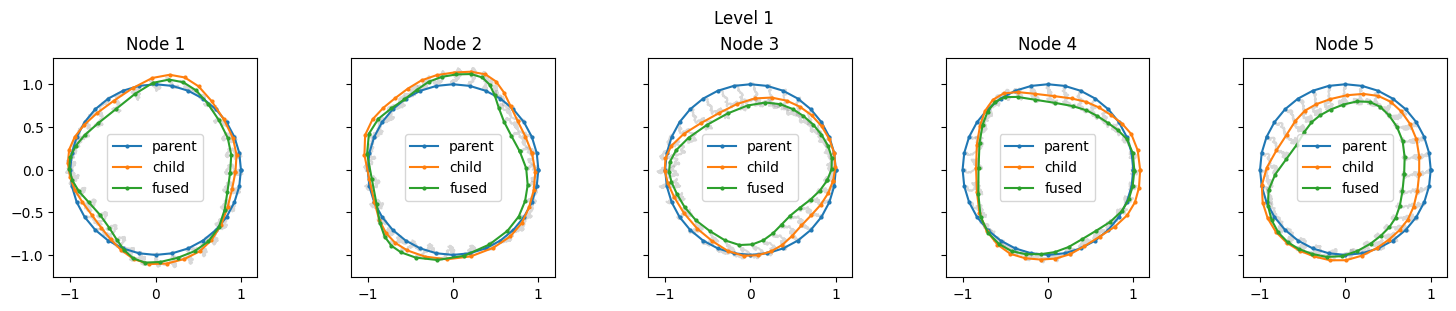

In [25]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharex=True, sharey=True, layout='constrained')

parent_shape = tree.data['value'][0]
closed_parent_curve = jnp.vstack([parent_shape, parent_shape[0:1, :]])

for i, node_id in enumerate(range(*tree.levels[1])):
    child_shape = tree.data['value'][node_id]
    closed_child_curve = jnp.vstack([child_shape, child_shape[0:1, :]])
    axs[i].plot(closed_parent_curve[:, 0], closed_parent_curve[:, 1], color='C0', marker='o', markersize=2, label='parent', zorder=2)
    axs[i].plot(closed_child_curve[:, 0], closed_child_curve[:, 1], color='C1', marker='o', markersize=2, label='child', zorder=2)
    
    path = tree.data['path'][node_id]
    for j in range(path.shape[1]):
        axs[i].plot(path[:, j, 0], path[:, j, 1], color='grey', alpha=0.3, zorder=1)
        
    endpoint = path[-1]
    closed_endpoint_curve = jnp.vstack([endpoint, endpoint[0:1, :]])
    axs[i].plot(closed_endpoint_curve[:, 0], closed_endpoint_curve[:, 1], color='C2', marker='o', markersize=2, label='fused', zorder=2)
    axs[i].set_title(f'Node {node_id}')
    axs[i].set_aspect('equal')
    axs[i].legend()
fig.suptitle('Level 1')
plt.show()

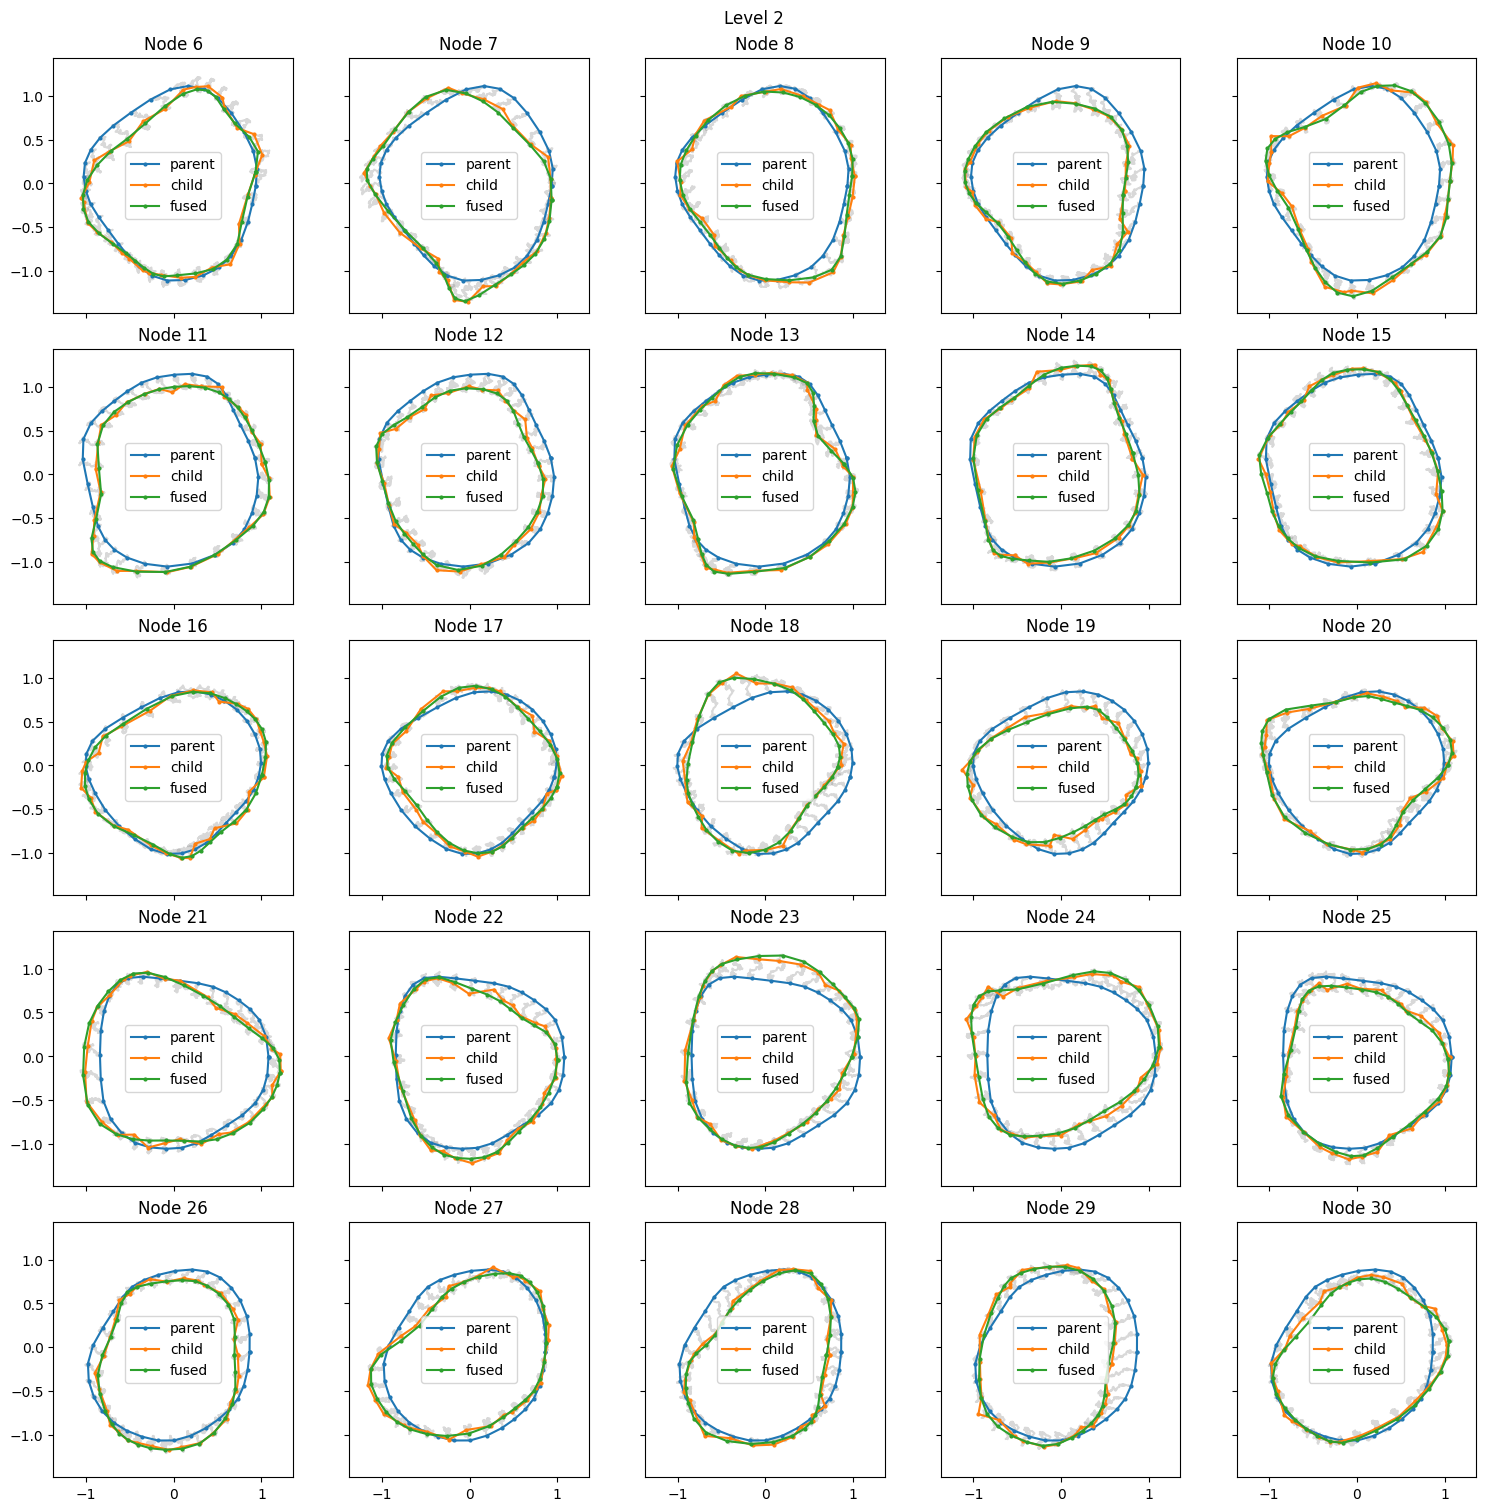

In [26]:
fig, axs = plt.subplots(5, 5, figsize=(15, 15), sharex=True, sharey=True, layout='constrained')

parent_level = tree.levels[1]
child_level = tree.levels[2]

for i, parent_node_id in enumerate(range(*parent_level)):
    parent_shape = tree.data['value'][parent_node_id]
    closed_parent_curve = jnp.vstack([parent_shape, parent_shape[0:1, :]])
    
    for j, child_node_id in enumerate(range(child_level[0] + i * 5, child_level[0] + (i + 1) * 5)):
        child_shape = tree.data['value'][child_node_id]
        closed_child_curve = jnp.vstack([child_shape, child_shape[0:1, :]])
        axs[i, j].plot(closed_parent_curve[:, 0], closed_parent_curve[:, 1], color='C0', marker='o', markersize=2, label='parent', zorder=2)
        axs[i, j].plot(closed_child_curve[:, 0], closed_child_curve[:, 1], color='C1', marker='o', markersize=2, label='child', zorder=2)

        path = tree.data['path'][child_node_id]
        for k in range(path.shape[1]):
            axs[i, j].plot(path[:, k, 0], path[:, k, 1], color='grey', alpha=0.3, zorder=1)

        endpoint = path[-1]
        closed_endpoint_curve = jnp.vstack([endpoint, endpoint[0:1, :]])
        axs[i, j].plot(closed_endpoint_curve[:, 0], closed_endpoint_curve[:, 1], color='C2', marker='o', markersize=2, label='fused', zorder=2)
        axs[i, j].set_title(f'Node {child_node_id}')
        axs[i, j].set_aspect('equal')
        axs[i, j].legend()
fig.suptitle('Level 2')
plt.show()

In [27]:
def log_likelihood(data, state):
    params, noise = state
    init_up(tree, data, params)
    up_executor.up(tree, params.values())

    # compute the tree log likelihood
    root_v = tree.data['value'][tree.is_root].squeeze()
    root_c = tree.data['cT'][tree.is_root].squeeze()
    root_F = tree.data['FT'][tree.is_root].squeeze()
    root_H = tree.data['HT'][tree.is_root].squeeze()
    root_log_likelihood = jnp.sum(root_c) +\
        jnp.einsum('ij,ij->', root_F, root_v) -\
            0.5 * jnp.einsum('id,ij,jd->', root_v, root_H, root_v)
            
    # update Wiener innovations
    tree.data['noise'] = noise
    # forward guiding downwards
    guiding_down_executor.down(tree, params.values())
    path_log_likelihood = jnp.sum(tree.data['log_Psi'][1:]) # exclude root node
    new_leaf_values = tree.data['path'][tree.is_leaf][:, -1, :, :]
    tree.data['value'] = tree.data['value'].at[tree.is_leaf].set(new_leaf_values)
    leaf_residuals = tree.data['value'][tree.is_leaf] - data
    leaf_log_likelihood = jax.vmap(
        lambda res: jax.scipy.stats.norm.logpdf(res, 0., jnp.sqrt(params['obs_var'].value)),
        in_axes=-1,
        out_axes=-1,
    )(leaf_residuals)
    # leaf_log_likelihood = jnp.mean(leaf_log_likelihood)
    leaf_log_likelihood = 0.0
    tree_log_likelihood = root_log_likelihood + path_log_likelihood + leaf_log_likelihood
    return tree_log_likelihood

def log_posterior(state, data):
    params, _ = state
    # log_prior = params.log_prior()
    log_priors = [v.log_prior() for k, v in params.params_dict.items() if k != "obs_var"]
    log_prior = jnp.sum(jnp.array(log_priors))
    log_liki= log_likelihood(data, state)
    return log_prior + log_liki

In [28]:
params_sampler = GibbsParametersSampler(tree)
# params_sampler = MHParametersSampler(tree)
noise_sampler = PCNNoiseSampler(eta=0.9)
state_sampler = AlternatingStateSampler(tree, params_sampler, noise_sampler)
# state_sampler = CanonicalStateSampler(tree, params_sampler, noise_sampler)
mcmc_sampler = MetropolisHastingsSampler(state_sampler)

init_params = ParameterStore({
    'k_alpha': VarianceParameter(
        value=0.2,
        prior_dist_hparams={'alpha': 2.0, 'beta': 0.5},
    ),
    'k_sigma': VarianceParameter(
        value=0.5,
    ),
    'obs_var': VarianceParameter(
        value=0.005,
        proposal_dist_hparams={'min': 1e-4, 'max': None},
        prior_dist_hparams={'alpha': 2.0, 'beta': 0.005},
    ),
})
print("Initial parameters: ", init_params.values())
print("True parameters: ", params.values())

init_state = (init_params, jnp.zeros_like(tree.data['noise']))

log_liki_history, samples = mcmc_sampler.sample(
    rng_key=key,
    log_posterior=log_posterior,
    log_likelihood=log_likelihood,
    data=noisy_leaf_shapes,
    init_state=init_state,
    num_samples=1000,
    num_burn_in=0,
    show_progress_bar=True
)

Initial parameters:  {'k_alpha': Array(0.2, dtype=float32), 'k_sigma': Array(0.5, dtype=float32), 'obs_var': Array(0.005, dtype=float32)}
True parameters:  {'k_alpha': Array(0.1, dtype=float32), 'k_sigma': Array(0.25, dtype=float32), 'obs_var': Array(0.001, dtype=float32)}


MCMC Sampling: 100%|██████████| 1000/1000 [03:05<00:00,  5.40it/s]

Overall acceptance rate: 0.3720


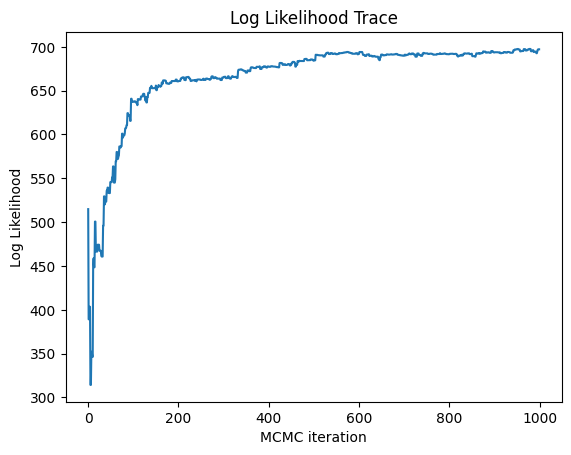

In [29]:
plt.plot(log_liki_history)
plt.xlabel('MCMC iteration')
plt.ylabel('Log Likelihood')
plt.title('Log Likelihood Trace')
plt.show()

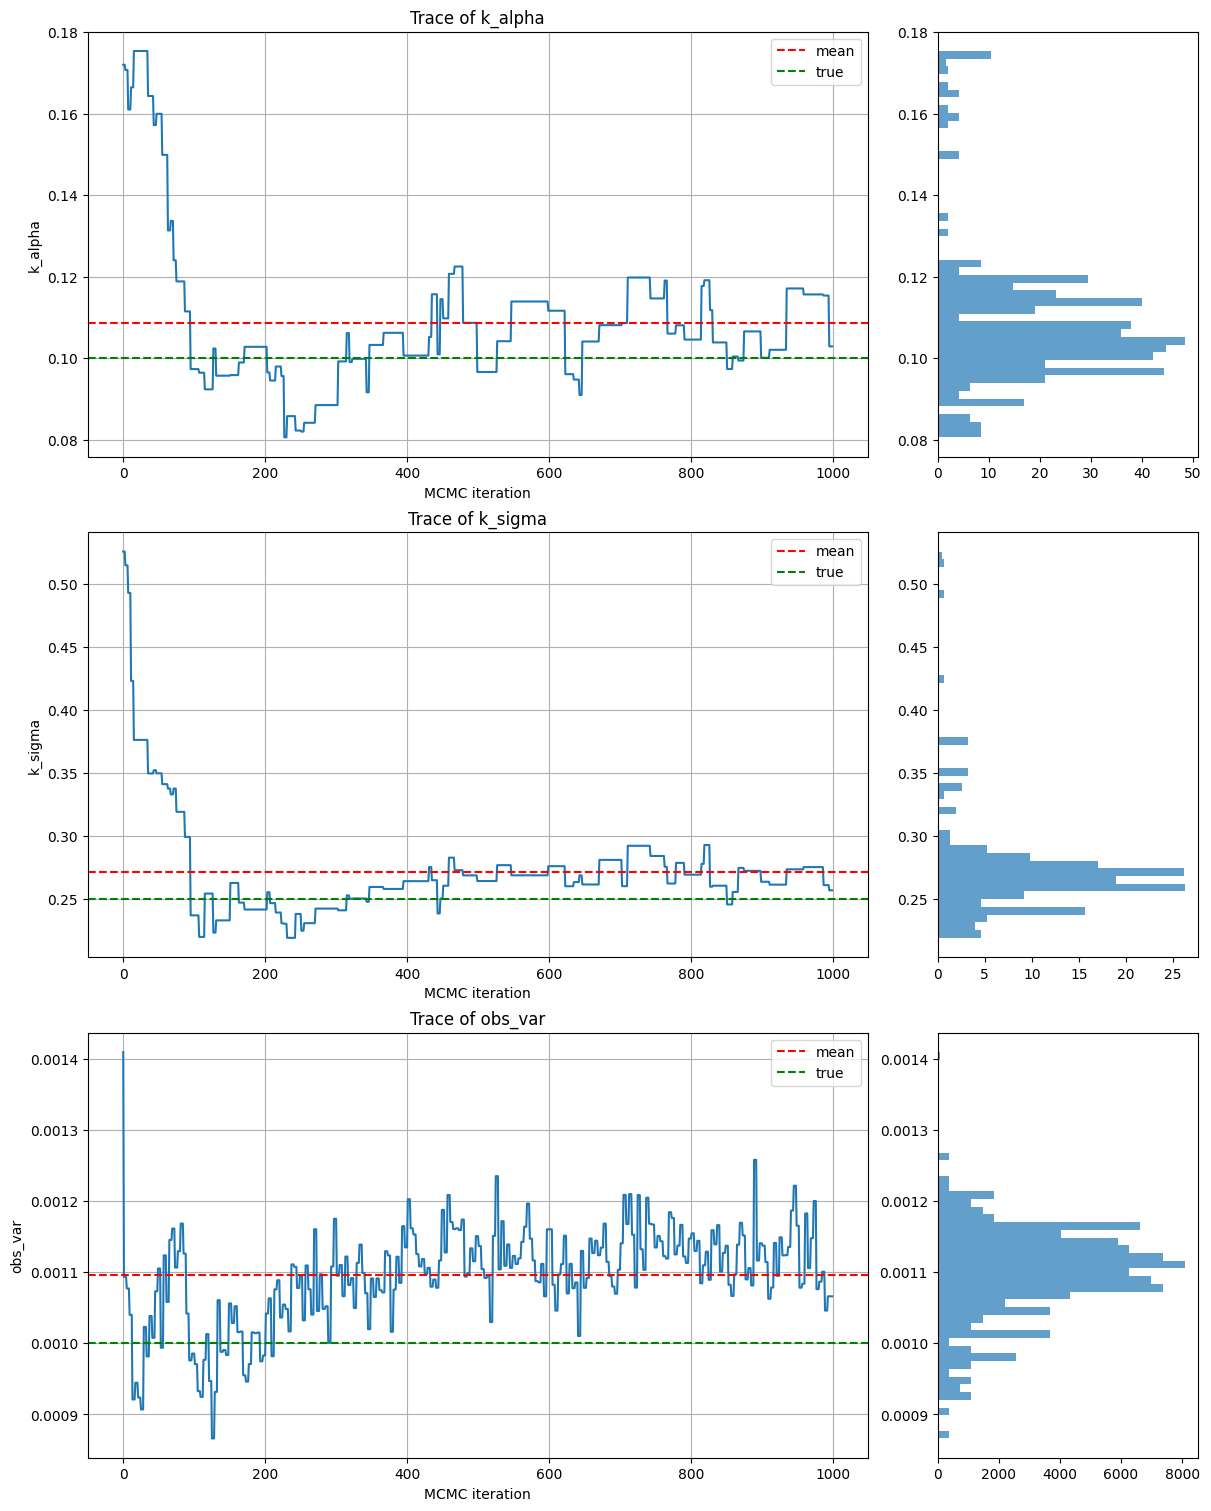

In [30]:
fig, axs = plt.subplots(3, 2, figsize=(12, 15), layout='constrained', gridspec_kw={'width_ratios': [3, 1]})
for i, (param_name, ax) in enumerate(zip(init_params.values().keys(), axs)):
    param_samples = jnp.array([sample[param_name].value for sample in samples])
    axs[i, 0].plot(param_samples)
    param_mean = jnp.mean(param_samples)
    axs[i, 0].axhline(param_mean, color='red', linestyle='--', label='mean')
    axs[i, 0].axhline(params[param_name].value, color='green', linestyle='--', label='true')
    axs[i, 0].set_title(f'Trace of {param_name}')
    axs[i, 0].legend()
    axs[i, 0].grid(True)
    axs[i, 0].set_xlabel('MCMC iteration')
    axs[i, 0].set_ylabel(param_name)
    
    axs[i, 1].hist(param_samples, bins=50, density=True, alpha=0.7, orientation='horizontal')
plt.show()